# Checkpoint 1 
## (Do not remove any comments that start with"# @@@".) 

Reminder: 

- You are being evaluated for completion and effort in this checkpoint. 
- Avoid manual labor / hard coding as much as possible, everything we've taught you so far are meant to simplify and automate your process.
- Please do not remove any comment that starts with: "# @@@". 

We will be working with the same `states_edu.csv` that you should already be familiar with from the tutorial.

We investigated Grade 8 reading score in the tutorial. For this checkpoint, you are asked to investigate another test. Here's an overview:

* Choose a specific response variable to focus on
>Grade 4 Math, Grade 4 Reading, Grade 8 Math
* Pick or create features to use
>Will all the features be useful in predicting test score? Are some more important than others? Should you standardize, bin, or scale the data?
* Explore the data as it relates to that test
>Create at least 2 visualizations (graphs), each with a caption describing the graph and what it tells us about the data
* Create training and testing data
>Do you want to train on all the data? Only data from the last 10 years? Only Michigan data?
* Train a ML model to predict outcome 
>Define what you want to predict, and pick a model in sklearn to use (see sklearn <a href="https://scikit-learn.org/stable/modules/linear_model.html">regressors</a>).


Include comments throughout your code! Every cleanup and preprocessing task should be documented.


<h2> Data Cleanup </h2>

Import `numpy`, `pandas`, and `matplotlib`.

(Feel free to import other libraries!)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Load in the "states_edu.csv" dataset and take a look at the head of the data

In [2]:
df = pd.read_csv("../data/states_edu.csv")
df.head(10)

,PRIMARY_KEY,STATE,YEAR,ENROLL,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,...,GRADES_4_G,GRADES_8_G,GRADES_12_G,GRADES_1_8_G,GRADES_9_12_G,GRADES_ALL_G,AVG_MATH_4_SCORE,AVG_MATH_8_SCORE,AVG_READING_4_SCORE,AVG_READING_8_SCORE
0,1992_ALABAMA,ALABAMA,1992,NaN,2678885.0,304177.0,1659028.0,715680.0,2653798.0,1481703.0,...,57948.0,58025.0,41167.0,NaN,NaN,731634.0,208.0,252.0,207.0,NaN
1,1992_ALASKA,ALASKA,1992,NaN,1049591.0,106780.0,720711.0,222100.0,972488.0,498362.0,...,9748.0,8789.0,6714.0,NaN,NaN,122487.0,NaN,NaN,NaN,NaN
2,1992_ARIZONA,ARIZONA,1992,NaN,3258079.0,297888.0,1369815.0,1590376.0,3401580.0,1435908.0,...,55433.0,49081.0,37410.0,NaN,NaN,673477.0,215.0,265.0,209.0,NaN
3,1992_ARKANSAS,ARKANSAS,1992,NaN,1711959.0,178571.0,958785.0,574603.0,1743022.0,964323.0,...,34632.0,36011.0,27651.0,NaN,NaN,441490.0,210.0,256.0,211.0,NaN
4,1992_CALIFORNIA,CALIFORNIA,1992,NaN,26260025.0,2072470.0,16546514.0,7641041.0,27138832.0,14358922.0,...,418418.0,363296.0,270675.0,NaN,NaN,5254844.0,208.0,261.0,202.0,NaN
5,1992_COLORADO,COLORADO,1992,NaN,3185173.0,163253.0,1307986.0,1713934.0,3264826.0,1642466.0,...,50648.0,45025.0,34533.0,NaN,NaN,612635.0,221.0,272.0,217.0,NaN
6,1992_CONNECTICUT,CONNECTICUT,1992,NaN,3834302.0,143542.0,1342539.0,2348221.0,3721338.0,2148041.0,...,38058.0,33691.0,28366.0,NaN,NaN,488476.0,227.0,274.0,222.0,NaN
7,1992_DELAWARE,DELAWARE,1992,NaN,645233.0,45945.0,420942.0,178346.0,638784.0,372722.0,...,8272.0,8012.0,6129.0,NaN,NaN,104321.0,218.0,263.0,213.0,NaN
8,1992_DISTRICT_OF_COLUMBIA,DISTRICT_OF_COLUMBIA,1992,NaN,709480.0,64749.0,0.0,644731.0,742893.0,329160.0,...,5832.0,5000.0,3433.0,NaN,NaN,80937.0,193.0,235.0,188.0,NaN
9,1992_FLORIDA,FLORIDA,1992,NaN,11506299.0,788420.0,5683949.0,5033930.0,11305642.0,5166374.0,...,164416.0,142372.0,100835.0,NaN,NaN,1981407.0,214.0,260.0,208.0,NaN


You should always familiarize yourself with what each column in the dataframe represents. Read about the states_edu dataset here: https://www.kaggle.com/noriuk/us-education-datasets-unification-project

Use this space to rename columns, deal with missing data, etc. _(optional)_

In [3]:
# Poke around with data
print(df.shape)
print(df.columns)

(1715, 25)
Index(['PRIMARY_KEY', 'STATE', 'YEAR', 'ENROLL', 'TOTAL_REVENUE',
       'FEDERAL_REVENUE', 'STATE_REVENUE', 'LOCAL_REVENUE',
       'TOTAL_EXPENDITURE', 'INSTRUCTION_EXPENDITURE',
       'SUPPORT_SERVICES_EXPENDITURE', 'OTHER_EXPENDITURE',
       'CAPITAL_OUTLAY_EXPENDITURE', 'GRADES_PK_G', 'GRADES_KG_G',
       'GRADES_4_G', 'GRADES_8_G', 'GRADES_12_G', 'GRADES_1_8_G',
       'GRADES_9_12_G', 'GRADES_ALL_G', 'AVG_MATH_4_SCORE', 'AVG_MATH_8_SCORE',
       'AVG_READING_4_SCORE', 'AVG_READING_8_SCORE'],
      dtype='str')


In [4]:
# Get a sense of count of missing values
for column in df.columns:
    print(column, df[column].isna().sum())

PRIMARY_KEY 0
STATE 0
YEAR 0
ENROLL 491
TOTAL_REVENUE 440
FEDERAL_REVENUE 440
STATE_REVENUE 440
LOCAL_REVENUE 440
TOTAL_EXPENDITURE 440
INSTRUCTION_EXPENDITURE 440
SUPPORT_SERVICES_EXPENDITURE 440
OTHER_EXPENDITURE 491
CAPITAL_OUTLAY_EXPENDITURE 440
GRADES_PK_G 173
GRADES_KG_G 83
GRADES_4_G 83
GRADES_8_G 83
GRADES_12_G 83
GRADES_1_8_G 695
GRADES_9_12_G 644
GRADES_ALL_G 83
AVG_MATH_4_SCORE 1150
AVG_MATH_8_SCORE 1113
AVG_READING_4_SCORE 1065
AVG_READING_8_SCORE 1153


In [5]:
len(df)

1715

In [6]:
# These variables will be used for modelling later
# Thus, rows containing nan for these columns are dropped (for simplicity)
df_clean = df[["AVG_MATH_4_SCORE", "ENROLL", "INSTRUCTION_EXPENDITURE", "AVG_READING_4_SCORE", "STATE_REVENUE"]].copy()
df_clean.dropna(inplace=True)
len(df_clean)

357

<h2>Exploratory Data Analysis (EDA) </h2>

Chosen one of Grade 4 Reading, Grade 4 Math, or Grade 8 Math to focus on: **Grade 4 Math**

How many years of data are logged in our dataset? 

In [7]:
# @@@ 1
# I am assuming "data" refers to the entire dataset, not just the chosen subset
print(df["YEAR"].unique())
len(df["YEAR"].unique())

[1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005
 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 1986 1987 1988
 1989 1990 1991 2017 2019]


33

Let's compare Michigan to Ohio. Which state has the higher average across all years in the test you chose?

In [8]:
# @@@ 2
mich_avg_score = df.loc[df['STATE'] == "MICHIGAN", "AVG_MATH_4_SCORE"].mean()
ohio_avg_score = df.loc[df['STATE'] == "OHIO", "AVG_MATH_4_SCORE"].mean()
# There's no way Ohio actually has a higher score 😭
mich_avg_score, ohio_avg_score

(np.float64(234.36363636363637), np.float64(239.45454545454547))

Find the average for your chosen test across all states in 2019

In [9]:
# @@@ 3
df.loc[df["YEAR"] == 2019, "AVG_MATH_4_SCORE"].mean()

np.float64(239.9433962264151)

For each state, find a maximum value for your chosen test score

In [10]:
# @@@ 4
df.groupby('STATE')["AVG_MATH_4_SCORE"].max()

STATE
ALABAMA                 233.0
ALASKA                  237.0
ARIZONA                 240.0
ARKANSAS                240.0
CALIFORNIA              235.0
COLORADO                247.0
CONNECTICUT             245.0
DELAWARE                243.0
DISTRICT_OF_COLUMBIA    235.0
DODEA                   250.0
FLORIDA                 246.0
GEORGIA                 240.0
HAWAII                  243.0
IDAHO                   242.0
ILLINOIS                239.0
INDIANA                 249.0
IOWA                    246.0
KANSAS                  248.0
KENTUCKY                242.0
LOUISIANA               234.0
MAINE                   246.0
MARYLAND                247.0
MASSACHUSETTS           253.0
MICHIGAN                238.0
MINNESOTA               253.0
MISSISSIPPI             241.0
MISSOURI                241.0
MONTANA                 244.0
NATIONAL                242.0
NEBRASKA                246.0
NEVADA                  237.0
NEW_HAMPSHIRE           253.0
NEW_JERSEY              249.0
NEW_

*Refer to the `Grouping and Aggregating` section in Tutorial 0 if you are stuck.

<h2> Feature Engineering </h2>

After exploring the data, you can choose to modify features that you would use to predict the performance of the students on your chosen response variable. 

You can also create your own features. For example, perhaps you figured that maybe a state's expenditure per student may affect their overall academic performance so you create a expenditure_per_student feature.

Use this space to modify or create features.

In [11]:
# @@@ 5
# See rationale below
df_clean["PER_CAPITA_INS_EXP"] = df_clean["INSTRUCTION_EXPENDITURE"] / df_clean["ENROLL"]
df_clean["PER_CAPITA_INS_EXP"][df_clean["PER_CAPITA_INS_EXP"].notna()]

561     3.870190
562     5.727741
563     3.212058
564     3.929094
565     4.747662
          ...   
1219    6.841255
1220    6.069762
1221    6.509767
1222    6.641202
1223    9.544462
Name: PER_CAPITA_INS_EXP, Length: 357, dtype: float64

Feature engineering justification: As per the example, I thought a per-capita rate was more sensible, so I added a similar feature `INS_EXP_PER_STUDENT`. The only difference is that it is limited to *instruction* expenditure.

<h2>Visualization</h2>

Investigate the relationship between your chosen response variable and at least two predictors using visualizations. Write down your observations.

**Visualization 1**

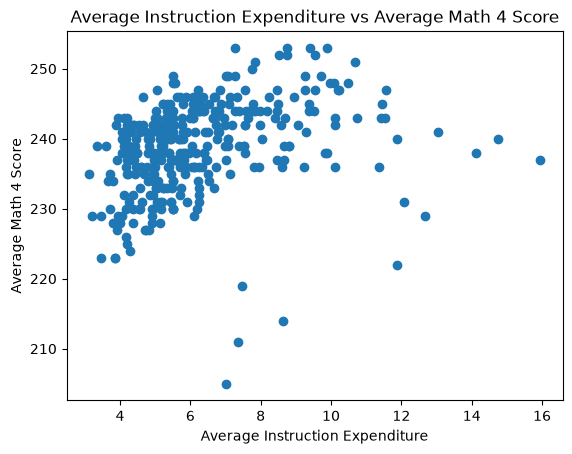

In [12]:
# @@@ 6
# Instruction Expenditure
plt.title("Average Instruction Expenditure vs Average Math 4 Score")
plt.xlabel("Average Instruction Expenditure")
plt.ylabel("Average Math 4 Score")
plt.scatter(df_clean["PER_CAPITA_INS_EXP"], df_clean["AVG_MATH_4_SCORE"])

There seems to be a weak (and somewhat nonlinear) relationship between *Average Instruction Expenditure* and *Math 4 Score*. Nevertheless, for simplicity, we will stick to linear regression for modelling.

**Visualization 2**

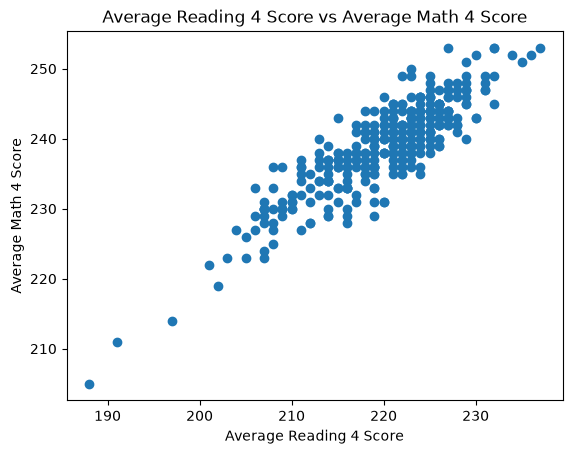

In [13]:
# @@@ 7
plt.title("Average Reading 4 Score vs Average Math 4 Score")
plt.xlabel("Average Reading 4 Score")
plt.ylabel("Average Math 4 Score")
plt.scatter(df_clean["AVG_READING_4_SCORE"], df_clean["AVG_MATH_4_SCORE"])

As expected, there is a strong positive linear relationship between *Average Math 4 score* and *Average Reading 4 score*.

**Visualization 3**

In [14]:
df_clean["PER_CAPITA_STATE_REVENUE"] = df_clean["STATE_REVENUE"] / df_clean["ENROLL"]

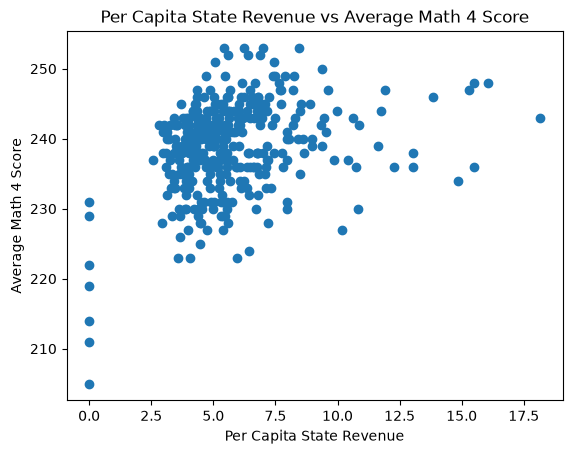

In [15]:
plt.title("Per Capita State Revenue vs Average Math 4 Score")
plt.xlabel("Per Capita State Revenue")
plt.ylabel("Average Math 4 Score")
plt.scatter(df_clean["PER_CAPITA_STATE_REVENUE"], df_clean["AVG_MATH_4_SCORE"])

There appears to be a weak linear relationship between *Per Capita State Revenue* and *Average Math 4 Score*. Let's also drop obviously inaccurate data points (those with zero state revenue).

In [16]:
(df_clean['PER_CAPITA_STATE_REVENUE'] == 0).sum()

np.int64(7)

In [17]:
df_clean = df_clean[df_clean['PER_CAPITA_STATE_REVENUE'] > 0]
(df_clean['PER_CAPITA_STATE_REVENUE'] == 0).sum()

np.int64(0)

<h2> Data Creation </h2>

_Use this space to create train/test data_

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
# @@@ 8
X = df_clean[["PER_CAPITA_INS_EXP", "AVG_READING_4_SCORE", "PER_CAPITA_STATE_REVENUE"]]
y = df_clean["AVG_MATH_4_SCORE"]

In [20]:
# @@@ 9 

X_train, X_test, y_train, y_test = train_test_split(
     X, y, test_size=0.3, random_state=42)

<h2> Prediction </h2>

ML Models [Resource](https://medium.com/@vijaya.beeravalli/comparison-of-machine-learning-classification-models-for-credit-card-default-data-c3cf805c9a5a)

In [21]:
# @@@ 10
# import your sklearn class here
from sklearn.linear_model import LinearRegression

In [22]:
# @@@ 11
# create your model here
model = LinearRegression()

In [23]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[-0.2 , 0.8 , 0.37]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['PER_CAPITA_INS_EXP','AVG_READING_4_SCORE','PER_CAPITA_STATE_REVENUE']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,62.54
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [24]:
y_pred = model.predict(X_test)

## Evaluation

Choose some metrics to evaluate the performance of your model, some of them are mentioned in the tutorial.

In [25]:
# @@@ 12
y_pred_train = model.predict(X_train)
r2 = model.score(X_test, y_test)
mae = np.mean(np.abs(model.predict(X_test) - y_test))
rmse = np.mean((model.predict(X_test) - y_test)**2)**0.5

print(f"R2 value: {r2:.3f}")    # ~0.669, there is room for improvement
print(f"Mean Absolute Error: {mae:.3f}")
print(f"Root Mean Squared Error: {rmse:.3f}")

R2 value: 0.669
Mean Absolute Error: 2.519
Root Mean Squared Error: 3.245


We have copied over the graphs that visualize the model's performance on the training and testing set. 

Change `col_name` and modify the call to `plt.ylabel()` to isolate how a single predictor affects the model.

Text(0.5, 1.0, 'Model Behavior On Training Set')

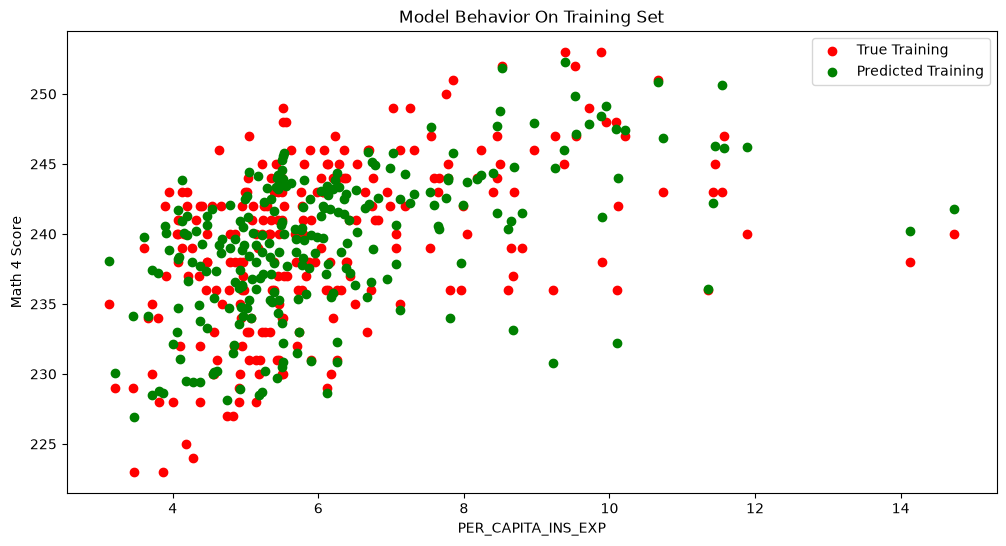

In [26]:
# @@@ 13
# This is for the *train* split

col_name = "PER_CAPITA_INS_EXP"

f = plt.figure(figsize=(12,6))
plt.scatter(X_train[col_name], y_train, color = "red")
plt.scatter(X_train[col_name], y_pred_train, color = "green")

plt.legend(['True Training','Predicted Training'])
plt.xlabel(col_name)
plt.ylabel('Math 4 Score')
plt.title("Model Behavior On Training Set")

Text(0.5, 1.0, 'Model Behavior on Testing Set')

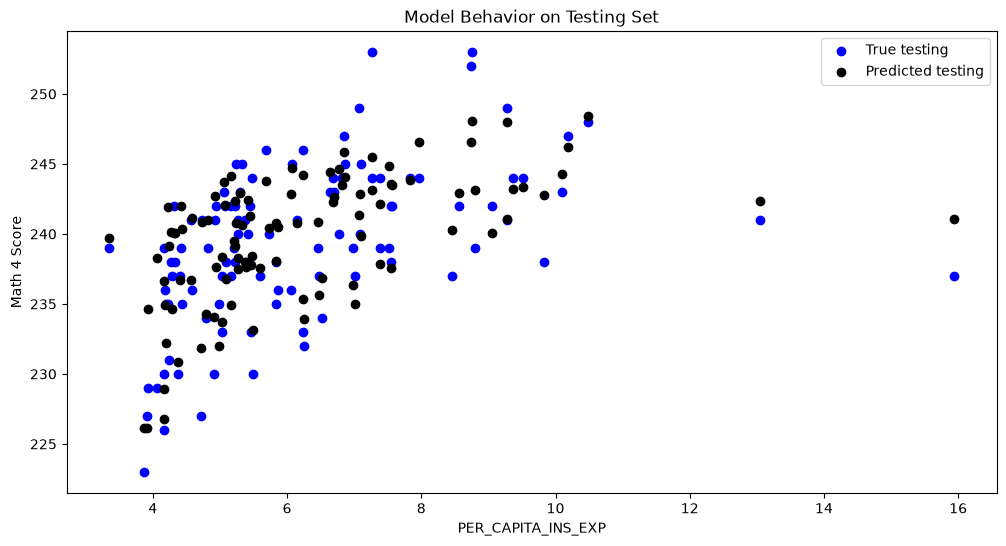

In [27]:
# @@@ 14
# This is for the *test* split

col_name = "PER_CAPITA_INS_EXP"

f = plt.figure(figsize=(12,6))
plt.scatter(X_test[col_name], y_test, color = "blue")
plt.scatter(X_test[col_name], y_pred, color = "black")

plt.legend(['True testing','Predicted testing'])
plt.xlabel(col_name)
plt.ylabel('Math 4 Score')
plt.title("Model Behavior on Testing Set")